### Minicurso Sistemas Multi-agente com LangGraph

## (1) Primeiro Grafo com um nó

Moacir Antonelli Ponti - 2025


---

In [ ]:
# colab notebook to install langchain
# %%capture
# !pip install langgraph

In [6]:
from typing import TypedDict, List
from langgraph.graph import StateGraph
from IPython.display import Image, display

Todo sistema agêntico possui um *estado* na memória, modificado pelos nós do grafo

In [7]:
# Estrutura do estado do agente
class AgentState(TypedDict):
    message : str
    

Os nós são definidos por meio de funções que recebem um um estado e retorna o estado

In [22]:
# Nó: sempre recebe um estado do agente e retorna um estado do agente
def primeiro_no(state: AgentState) -> AgentState:
    """Nó que adiciona uma saudação à mensagem de estado do agente"""

    if isinstance(state['message'], str):
        state['message'] = "Olá " + state["message"] + ", tudo bem por aí?"

    return state

O grafo é inicializado com a classe definida com o estado do agente, e na sequência adicionamos nós, arestas, e definimos pontos de entrada e finalização

In [23]:
# usamos as funcoes add_node, set_entry_point, set_finish_point e compile
graph = StateGraph(AgentState)
graph.add_node(node="inicio", action=primeiro_no)
graph.set_entry_point("inicio")
graph.set_finish_point("inicio")
app = graph.compile()

In [24]:
app.invoke({'message': 'Moacir'})

{'message': 'Olá Moacir, tudo bem por aí?'}

In [28]:
res = app.invoke({'message': 'pessoal do Data e RAIA'})
print(res['message'])

Olá pessoal do Data e RAIA, tudo bem por aí?


In [29]:
app.invoke({'message': 1})

{'message': 1}

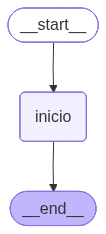

In [10]:
display(Image(app.get_graph().draw_mermaid_png()))

---

Vamos fazer um agente com mais entradas e memória que devolva a soma de valores numa lista, ex.

```
res = app.invoke({"name" : "Moa", "values" : [1,2,3]})
print(res['result'])
```

In [49]:
# a state with multiple inputs/memory
class AgentState(TypedDict):
    name : str
    values: List[float]
    result: float

def process_values(state: AgentState) -> AgentState:
    """Somar valores da lista values e atualizar o resultado do estado"""
    # print(state.keys())
    state['result'] = sum(state['values'])
    state['print_result'] = f"Olá {state['name']} o resultado é = {state['result']}"
    return state

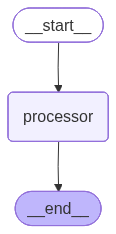

In [50]:
graph = StateGraph(AgentState)
graph.add_node("processor", process_values)
graph.set_entry_point("processor")
graph.set_finish_point("processor")
app = graph.compile()

display(Image(app.get_graph().draw_mermaid_png()))

In [51]:
res = app.invoke({"name" : "Moa", "values" : [1,2,3]})
print(res['result'])

6


In [57]:
res = app.invoke({"name" : "Moa", "values" : [1,2,3,5,10], "result": None, "print_result": None})
print(res['result'])
# print(res['print_result']) # isso aqui dá erro

21


## Exercício:

Escreva um agente que receba uma lista de valores, uma operação de redução e gere o resultado no formato:
`Resultado = {valor}`

Operações permitidas: + (soma) ou * (produto)

Caso a operação não seja válida, o resultado deve ser `Operação inválida`